# Fitting a binary's orbit to interferometric data

A long-baseline interferometer resolves a close binary into two stars, and if we observe it again over months and years we can watch the companion move around its primary. This tutorial infers the Keplerian orbit **directly from the interferometric data of every epoch at once**: one model predicts the squared visibilities and closure phases of all the nights, with the companion at its orbital position at the time of each measurement, and one sampler explores the orbit, the flux ratio and each night's calibration together.

**What you'll get.** The orbit, recovered from eight epochs that cover about half of it:

![150 orbits drawn from the joint posterior (blue), the true orbit (red), and the companion's position at each epoch implied by the posterior](generated/orbit_fitting_cell031_out01.png)

*150 orbits drawn from the joint posterior (blue) around the true orbit (red). The markers are the companion's positions at the eight epochs implied by the posterior, coloured by time: they are derived from the orbit, not measured separately. The orbits spread most near the unobserved periastron, south of the primary.*

The classical route is in two steps: measure the companion's position at each epoch, then fit an orbit to the positions. It is quick, but it throws information away. Each epoch's position is summarised by a Gaussian, which is poor when a night's likelihood is skewed or has several peaks, and each epoch's error scale must be settled before the orbit is fitted. Here we skip that compression:

1. **Simulate** eight VLTI-like epochs of a mildly eccentric binary, whose quoted errors underestimate the real scatter by a different factor each night, as they do for real data.
2. **Write one model** for all the data: a `KeplerOrbit` places the companion at the time of every sample.
3. **Add hierarchical calibration nuisances**: one error scale per epoch for $V^2$ and one for closure phases, drawn from a population whose median and spread are fitted too.
4. **Initialise** cheaply, with coarse per-epoch grids and a Thiele–Innes grid over orbits, ranked against the data. This is only a starting point, not the inference.
5. **Sample** the joint posterior with NUTS and check the sampler.
6. **Look** at the orbit on the sky and in time, at the positions it implies, at the data it predicts and at the calibration it infers.
7. **Compare** with the two-step result.

The orbit conventions are those of [Conventions](conventions.md#orbits): `Omega` is the position angle of the node where the secondary recedes, `omega` is the secondary's argument of periastron, an inclination below 90° means the position angle increases with time, and times are days since a reference epoch `t_ref`.

We need numpyro for the sampler and virgil's coverage, fitting, orbit and prior tools. `plot_orbit_ensemble` draws orbits on the sky, `plot_chainconsumer_diagnostics` draws the corner plot, and `set_style` applies the figure style used throughout the docs. We sample in double precision: the likelihood sums a few thousand terms, and NUTS's energy checks are more reliable when that sum is accurate.

In [1]:
import warnings

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro.distributions as dist
import pandas as pd
from numpyro.diagnostics import summary
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_value
from tqdm.auto import tqdm

from virgil.angles import AngleVector
from virgil.coverage import vlti_oidata
from virgil.fitting import fit
from virgil.grid_fit import best_grid_point, likelihood_grid
from virgil.inference import laplace_cov
from virgil.likelihood import model_loglike, numpyro_model
from virgil.likelihood import whitened_residuals
from virgil.models import Attached, BinaryModelCartesian, PointSource, System
from virgil.orbits import (
    KeplerOrbit,
    PositionData,
    orientation_priors,
    starting_orbits,
    total_mass,
)
from virgil.plotting import (
    plot_chainconsumer_diagnostics,
    plot_orbit_ensemble,
    set_style,
)
from virgil.priors import hierarchical_scales
from virgil.simulate import simulate

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", message="IProgress not found.*")
set_style()

## The system

The binary is the one of the earlier two-step version of this tutorial: a period of about three years, a mildly eccentric orbit ($e = 0.3$), an angular semimajor axis of 25 mas and an inclination of 55°. The companion is 0.15 times as bright as the primary in the K band. We place it at 105 pc, which we treat as known exactly when we turn the orbit into a total mass.

The eight epochs fall in two observing seasons and cover about half of the orbit. The periastron passage is not observed: the last epoch is about ten months before the next one. Times are measured from a reference epoch near the middle of the observations, `T_REF`, which keeps the period and the orbital phase there nearly uncorrelated.

In [2]:
T_REF = 60280.0  # MJD near the middle of the epochs
T_PERI = 59780.0  # MJD of a periastron passage
DISTANCE_PC = 105.0  # assumed known exactly, for the total mass
FLUX = 0.15  # companion / primary
TRUTH = dict(
    period=1100.0,
    dt_peri=T_PERI - T_REF,
    ecc=0.3,
    inc=55.0,
    omega=70.0,
    Omega=130.0,
    a_mas=25.0,
)
truth_orbit = KeplerOrbit(**TRUTH, t_ref=T_REF)
NIGHTS = 60000.0 + np.array([0.0, 35, 95, 150, 330, 385, 445, 560])
N_EPOCHS = len(NIGHTS)

next_peri = T_PERI + TRUTH["period"]
print(
    f"period {TRUTH['period'] / 365.25:.2f} yr, total mass "
    f"{float(total_mass(truth_orbit, DISTANCE_PC)):.2f} M_sun at "
    f"{DISTANCE_PC:.0f} pc"
)
print(
    f"the epochs span {np.ptp(NIGHTS) / TRUTH['period']:.0%} of the "
    f"orbit; the next periastron is at MJD {next_peri:.0f}"
)

period 3.01 yr, total mass 1.99 M_sun at 105 pc
the epochs span 51% of the orbit; the next periastron is at MJD 60880


## Simulating the observations

[`vlti_oidata`](api/coverage.md) builds the coverage of the four 8-m Unit Telescopes at Paranal for a target at declination −30°: three snapshots per night, two hours apart either side of transit, each with all six baselines and four closure triangles, in six K-band channels (2.0–2.4 μm). Passing `nights_mjd` repeats this on every night and stamps each snapshot with its own time. The quoted errors are 0.05 on each $V^2$ and 3° on each closure phase.

Real calibrated errors are rarely right. They are usually too small, by a factor that changes from night to night with the seeing, the calibrators and the instrument's state, and differently for $V^2$ and for closure phases. We mimic this: each night's true scatter is its quoted error times a factor drawn from a log-normal population (median 1.3, spread 0.3 in the natural log), separately for $V^2$ and closure phases, while the data keep the quoted errors. The model will have to find these factors.

The scene is a primary point source and a companion `Attached` to the true orbit, so [`simulate`](api/simulate.md) evaluates the companion's position at the time of each sample. We simulate each night twice with a fixed seed, once at its $V^2$ noise level and once at its closure-phase level, and keep the $V^2$ of the first and the closure phases of the second. `binary_scene` builds this scene for any orbit and flux ratio; it is the model we will fit.

In [3]:
rng = np.random.default_rng(11)
TRUE_V2_SCALE = 1.3 * np.exp(0.3 * rng.standard_normal(N_EPOCHS))
TRUE_CP_SCALE = 1.3 * np.exp(0.3 * rng.standard_normal(N_EPOCHS))

template = vlti_oidata(
    declination_deg=-30.0,
    hour_angles_h=(-2.0, 0.0, 2.0),
    wavelengths_m=np.linspace(2.0e-6, 2.4e-6, 6),
    sigma_v2=0.05,
    sigma_cp_deg=3.0,
    nights_mjd=NIGHTS,
)


def binary_scene(orbit, flux):
    return System(
        primary=PointSource(), comp=Attached(PointSource(flux), orbit)
    )


truth_scene = binary_scene(truth_orbit, FLUX)
keys = jax.random.split(jax.random.PRNGKey(2026), 2 * N_EPOCHS)
epochs = []
for k, night in enumerate(template.split_by_epoch()):
    v2 = simulate(truth_scene, night, keys[2 * k], TRUE_V2_SCALE[k])
    cp = simulate(truth_scene, night, keys[2 * k + 1], TRUE_CP_SCALE[k])
    epochs.append(eqx.tree_at(lambda d: d.phi, v2, cp.phi))
epoch_mjd = np.array([float(np.mean(night.mjd)) for night in epochs])
print(
    f"{len(epochs)} epochs, each with {epochs[0].vis.size} V² and "
    f"{epochs[0].phi.size} closure phases ({epochs[0].n_independent} "
    "independent observables)"
)

8 epochs, each with 108 V² and 72 closure phases (162 independent observables)


The quoted errors are too small, and the data show it. The reduced χ² of the *true* model against each night's data, with the quoted errors, is close to the square of that night's error factor, for $V^2$ and closure phases alike. A fit that trusted the quoted errors would weight the worst nights most heavily relative to their real quality, and would report intervals that are too narrow.

In [4]:
print("   MJD    χ²_r V²  (true factor²)   χ²_r CP  (true factor²)")
for k, night in enumerate(epochs):
    w = np.asarray(whitened_residuals(truth_scene, night))
    n_vis = night.vis.size
    n_cp = night.n_independent - n_vis
    chi2_v2 = np.sum(w[:n_vis] ** 2) / n_vis
    chi2_cp = np.sum(w[n_vis:] ** 2) / n_cp
    print(
        f"{epoch_mjd[k]:8.1f}  {chi2_v2:6.2f}   ({TRUE_V2_SCALE[k] ** 2:5.2f})"
        f"         {chi2_cp:6.2f}   ({TRUE_CP_SCALE[k] ** 2:5.2f})"
    )

   MJD    χ²_r V²  (true factor²)   χ²_r CP  (true factor²)


 60000.0    1.68   ( 1.73)           2.58   ( 2.65)
 60035.0    3.19   ( 3.82)           0.45   ( 0.56)


 60095.0    3.31   ( 3.52)           3.22   ( 4.33)


 60150.0    1.10   ( 1.24)           1.28   ( 1.59)


 60330.0    1.66   ( 1.41)           1.79   ( 2.54)


 60385.0    0.83   ( 1.23)           1.47   ( 1.56)


 60445.0    2.15   ( 2.38)           1.25   ( 1.35)


 60560.0    1.69   ( 1.63)           0.99   ( 2.23)


The left panel shows the uv coverage of the first night, coloured by wavelength: Earth rotation carries each baseline along a short track, and the spread of channels stretches it radially. The right panel shows the true orbit on the sky (East to the left, North up), with the companion's position at each of the eight epochs and the unobserved periastron marked.

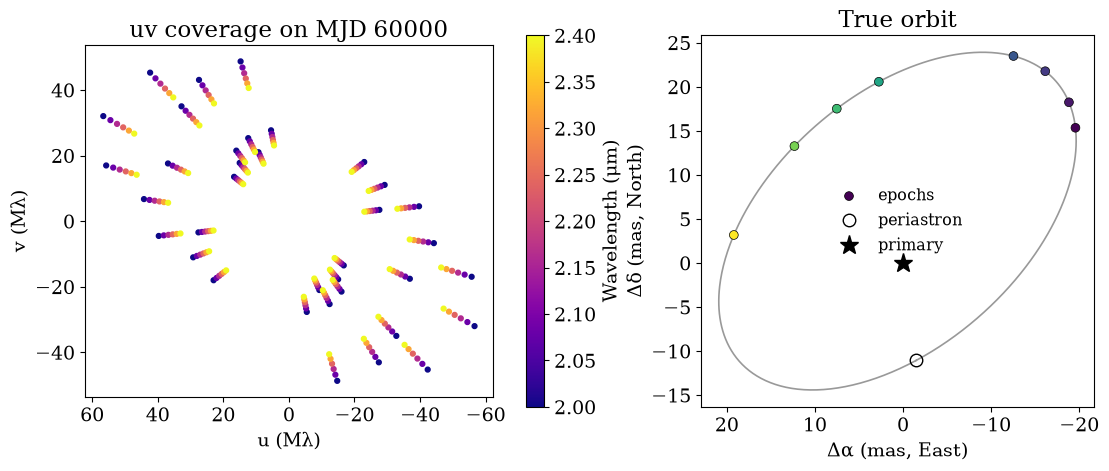

In [5]:
fig, (ax_uv, ax_sky) = plt.subplots(
    1, 2, figsize=(11, 4.6), constrained_layout=True
)
first = epochs[0]
uu, vv = (np.asarray(x / first.wavel) / 1e6 for x in (first.u, first.v))
wavel_um = np.asarray(first.wavel) * 1e6
for sign in (1, -1):
    points = ax_uv.scatter(
        sign * uu, sign * vv, c=wavel_um, cmap="plasma", s=12
    )
fig.colorbar(points, ax=ax_uv, label="Wavelength (μm)")
ax_uv.set(
    xlabel="u (Mλ)",
    ylabel="v (Mλ)",
    aspect="equal",
    title=f"uv coverage on MJD {NIGHTS[0]:.0f}",
)
ax_uv.invert_xaxis()  # East to the left

track = T_PERI + np.linspace(0, TRUTH["period"], 400)
dra, ddec, _ = truth_orbit.relative(track)
night_dra, night_ddec, _ = truth_orbit.relative(epoch_mjd)
ax_sky.plot(dra, ddec, color="0.6", lw=1.2)
ax_sky.scatter(
    night_dra,
    night_ddec,
    c=epoch_mjd,
    cmap="viridis",
    s=40,
    edgecolors="k",
    linewidths=0.5,
    zorder=3,
    label="epochs",
)
ax_sky.plot(
    dra[0], ddec[0], "o", mfc="none", mec="k", ms=9, label="periastron"
)
ax_sky.plot(0, 0, "*", color="k", ms=14, label="primary")
ax_sky.set(
    xlabel="Δα (mas, East)",
    ylabel="Δδ (mas, North)",
    aspect="equal",
    title="True orbit",
)
ax_sky.invert_xaxis()
ax_sky.legend(frameon=False, fontsize="small")
plt.show()

## One model for all the data

The model is a function of the sampled parameters that returns a scene. It builds a `KeplerOrbit` and attaches the companion to it, and [`OIData.model`](api/oidata.md) evaluates the scene at each sample's own time. So the same function, with the same parameters, predicts every epoch, and the companion even moves within a night (by under 0.02 mas here). There is no per-epoch position anywhere in the model.

We sample the orbit's orientation as two angles that the data identify, rather than $\Omega$ and $\omega$ themselves. Sky positions, and therefore visibilities and closure phases, cannot tell $(\Omega, \omega)$ from $(\Omega + 180°, \omega + 180°)$: the second orbit is the first with the line of sight reversed. Sampling $2\Omega$ and the longitude of periastron $\varpi = \Omega + \omega$ instead maps both onto one point, so this exact mirror mode disappears ([`orientation_priors`](api/orbits.md), [`KeplerOrbit.from_varpi`](api/orbits.md)). $\Omega$ is then reported in [0°, 180°), the usual convention for visual orbits; radial velocities would be needed to fix it absolutely. The time of periastron is sampled as `phase`, the mean anomaly at `T_REF` in degrees.

In [6]:
def orbit_from(v):
    # The orbit for a dict of sampled values (or arrays of samples).
    return KeplerOrbit.from_varpi(
        v["period"],
        -v["period"] * v["phase"] / 360.0,  # dt_peri from the mean anomaly
        v["ecc"],
        v["inc"],
        v["varpi"],
        v["a_mas"],
        two_Omega=v["two_Omega"],
        t_ref=T_REF,
    )


def scene_fn(**v):
    return binary_scene(orbit_from(v), v["flux"])

## Priors

Every prior is the invariant (Jeffreys) measure of the group that acts on its parameter, unless there is strong information otherwise:

| Parameter | Prior | Why it is the invariant choice |
|---|---|---|
| Period $P$ | log-uniform, 100–10⁴ d | A scale: invariant under a change of the unit of time. |
| Semimajor axis $a$ | log-uniform, 1–300 mas | A scale, invariant under rescaling of angles. |
| Inclination $i$ | `IsotropicInclination` (from `orientation_priors(inclination=True)`), ∝ sin i | An isotropic orbital plane: the Haar measure on rotations, uniform in cos i. |
| $2\Omega$, $\varpi$ | `AngleVector`, uniform on the circle | The same rotation-invariant measure; the map from $(\Omega, \omega)$ is linear, so uniform stays uniform. |
| Mean anomaly at `T_REF` | `AngleVector`, uniform | A location in time: uniform in the time of periastron over one period. |
| Eccentricity $e$ | uniform on [0, 1) | No group acts on $e$: an interim prior, which a population prior can later reweight. |
| Flux ratio | log-uniform, 10⁻³–1 | A scale. |
| Error scales: population median and spread | log-uniform, 0.1–10 and 0.01–1 | Scales. |

Each `AngleVector` samples a 2-vector whose direction is the angle, so there is no wall at 0°/360°. Its length is a nuisance with a ring-shaped prior, $\exp[-(r - 1)^2/2s^2]$, which leaves the angle exactly uniform. The width $s$ matters to the sampler, not to the prior on the angle. The data fix these angles to a fraction of a degree, so near radius $r$ the posterior is a thin wedge of width proportional to $r$; if $r$ ranged widely, the wedge would narrow into a funnel towards the origin and NUTS would diverge. We take $s = 0.1$, which keeps $r$ within about 20% of 1 and the wedge's width nearly constant ([`AngleVector`](api/angles.md)).

**Hierarchical error scales.** Each epoch $k$ gets a factor $s_k$ multiplying its quoted $V^2$ errors and a factor $c_k$ multiplying its closure-phase errors. Treating these as independent unknowns would be valid, but they are not unrelated: they come from one instrument and one pipeline. So we give them a population: $\log s_k$ is normal about the log of a median with a fitted spread, and likewise for $c_k$. [`hierarchical_scales`](api/priors.md) returns the priors and one callable per epoch, which we pass as `noise=` terms tied to the parameters. This matters most for real data with uneven epochs: a night with few frames, whose own scale is poorly measured, borrows strength from the others instead of being free to inflate its errors and drop out of the fit. And the population's median and spread are useful numbers in themselves: they say how far the pipeline's errors are off. Here every night has well over a hundred observables, so each scale is measured well; virgil then uses the *centred* form (sampling $\log s_k$ directly), which NUTS handles without divergences in that regime.

In [7]:
orbit_priors = {
    "period": dist.LogUniform(100.0, 1e4),
    "a_mas": dist.LogUniform(1.0, 300.0),
    "ecc": dist.Uniform(0.0, 1.0),
    # "inc" (isotropic), and "two_Omega" and "varpi" as angle vectors
    # with a narrow ring: the full invariant prior on the orientation
    **orientation_priors(ring_width=0.1, inclination=True),
    "phase": AngleVector(ring_width=0.1),
}
v2_population, v2_scales = hierarchical_scales("v2_scale", N_EPOCHS)
cp_population, cp_scales = hierarchical_scales("cp_scale", N_EPOCHS)
priors = {
    **orbit_priors,
    "flux": dist.LogUniform(1e-3, 1.0),
    **v2_population,
    **cp_population,
}
noise = [
    {"vis_scale": v2_scales[k], "phi_scale": cp_scales[k]}
    for k in range(N_EPOCHS)
]


def run_nuts(model, seed, num_warmup, num_samples, num_chains=1, init=None):
    strategy = (
        {} if init is None else {"init_strategy": init_to_value(values=init)}
    )
    kernel = NUTS(model, dense_mass=True, target_accept_prob=0.9, **strategy)
    mcmc = MCMC(
        kernel,
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=num_chains,
        chain_method="vectorized",
        progress_bar=False,
    )
    mcmc.run(jax.random.PRNGKey(seed))
    return mcmc

### Prior check

A sampler should reproduce its prior when there are no data, Jacobians included. [`numpyro_model`](api/likelihood.md) builds the model from the orbit and flux priors with no data, and a short NUTS run samples it. The histograms of the derived elements match the stated densities (dashed): log-uniform $P$, $a$ and flux ratio, uniform $e$ and $\cos i$, the $\sin i$ density of an isotropic orientation, and flat angles. (The error-scale population is a log-normal with log-uniform hyperpriors; its own no-data test is in virgil's test suite.)

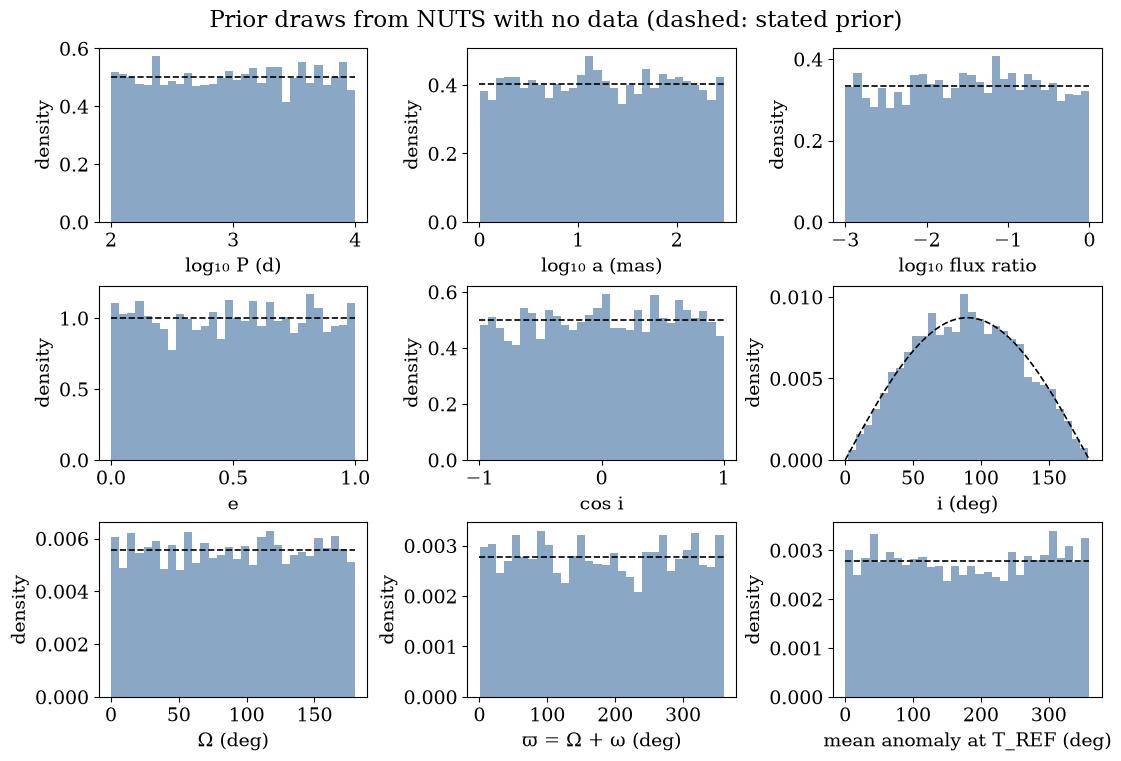

In [8]:
prior_model = numpyro_model(
    scene_fn, {**orbit_priors, "flux": priors["flux"]}, ()
)
prior = run_nuts(prior_model, seed=1, num_warmup=500, num_samples=4000)
draws = {k: np.asarray(v) for k, v in prior.get_samples().items()}


def flat(lo, hi):
    return [lo, hi], [1 / (hi - lo)] * 2


inc_grid = np.linspace(0, 180, 100)
panels = [
    ("log₁₀ P (d)", np.log10(draws["period"]), *flat(2, 4)),
    ("log₁₀ a (mas)", np.log10(draws["a_mas"]), *flat(0, np.log10(300))),
    ("log₁₀ flux ratio", np.log10(draws["flux"]), *flat(-3, 0)),
    ("e", draws["ecc"], *flat(0, 1)),
    ("cos i", np.cos(np.radians(draws["inc"])), *flat(-1, 1)),
    (
        "i (deg)",
        draws["inc"],
        inc_grid,
        np.sin(np.radians(inc_grid)) * np.pi / 360,
    ),
    ("Ω (deg)", draws["two_Omega"] / 2, *flat(0, 180)),
    ("ϖ = Ω + ω (deg)", draws["varpi"], *flat(0, 360)),
    ("mean anomaly at T_REF (deg)", draws["phase"], *flat(0, 360)),
]
fig, axes = plt.subplots(3, 3, figsize=(11, 7.5), constrained_layout=True)
for ax, (label, samples, x, density) in zip(axes.flat, panels):
    ax.hist(samples, bins=30, density=True, color="#3c6e9f", alpha=0.6)
    ax.plot(x, density, "k--", lw=1.2)
    ax.set(xlabel=label, ylabel="density")
fig.suptitle("Prior draws from NUTS with no data (dashed: stated prior)")
plt.show()

## Initialisation (not inference)

NUTS explores one mode well but does not search for it, so it needs a start in the right basin. Finding the basin is cheap if we borrow the classical tools, as long as we treat their output only as a starting point. Nothing from this section enters the posterior.

**Per-epoch grids.** For each night we compute the likelihood of a static binary on a coarse grid of positions (±40 mas in steps of 1 mas, finer than the resolution λ/B ≈ 3.5 mas of the longest baseline) and flux ratios, and keep the best grid point. We also record how decisive the night is: the gap in log likelihood between the best peak and the best one more than 4 mas away. On these clean simulated nights every gap is large. **On real data, per-epoch closure-phase surfaces are often strongly multimodal**, and a night's best peak can sit away from the true orbit. Use only decisive nights to seed orbits (here a gap above 5), and let the joint fit judge the rest.

In [9]:
axis = np.linspace(-40.0, 40.0, 81)
grid = {"dra": axis, "ddec": axis, "flux": np.geomspace(0.02, 0.5, 6)}
xx, yy = np.meshgrid(axis, axis, indexing="ij")

quick = []
for night in tqdm(epochs, desc="per-epoch grids"):
    loglike_grid = np.asarray(
        likelihood_grid(night, BinaryModelCartesian, grid)
    )
    best = best_grid_point(loglike_grid, grid)
    by_position = loglike_grid.max(axis=2)  # best flux at each position
    far = np.hypot(xx - best["dra"], yy - best["ddec"]) > 4.0
    gap = by_position.max() - by_position[far].max()
    quick.append({**{k: float(v) for k, v in best.items()}, "gap": gap})

true_dra, true_ddec, _ = (np.asarray(x) for x in truth_orbit.relative(epoch_mjd))
print("    MJD   grid Δα  true Δα   grid Δδ  true Δδ  flux   gap")
for t, q, ra, de in zip(epoch_mjd, quick, true_dra, true_ddec):
    print(
        f"{t:8.1f}  {q['dra']:6.1f}  {ra:7.2f}   {q['ddec']:6.1f}  {de:7.2f}"
        f"  {q['flux']:.2f}  {q['gap']:5.0f}"
    )

per-epoch grids:   0%|          | 0/8 [00:00<?, ?it/s]

    MJD   grid Δα  true Δα   grid Δδ  true Δδ  flux   gap
 60000.0   -19.0   -19.57     15.0    15.34  0.14    862
 60035.0   -19.0   -18.83     18.0    18.24  0.14    750
 60095.0   -16.0   -16.14     22.0    21.76  0.14    796
 60150.0   -12.0   -12.53     23.0    23.49  0.14    746
 60330.0     3.0     2.74     20.0    20.56  0.14    687
 60385.0     7.0     7.52     18.0    17.51  0.14    635
 60445.0    12.0    12.33     14.0    13.26  0.14    349
 60560.0    19.0    19.21      3.0     3.17  0.14    909


**Starting orbits.** At a fixed period, eccentricity and time of periastron the sky positions are linear in the four Thiele–Innes constants, so each point of a grid in those three is an exact weighted least-squares solve. [`starting_orbits`](api/orbits.md) runs this grid (here 160 periods from 300 to 5000 days, eccentricities from 0 to 0.9 and 36 times of periastron per period) on the decisive nights' grid positions, with a generous 0.5 mas error each. With few seed positions many orbits fit them almost equally well, so we keep the best 200 and **rank them by the likelihood of the interferometric data of all the epochs**, at the median grid flux ratio, rather than by the fit to the rough positions. The ranking is one vectorised evaluation of the joint model.

In [10]:
decisive = [k for k, q in enumerate(quick) if q["gap"] > 5.0]
seeds = PositionData(
    epoch_mjd[decisive],
    [quick[k]["dra"] for k in decisive],
    [quick[k]["ddec"] for k in decisive],
    np.tile(0.5**2 * np.eye(2), (len(decisive), 1, 1)),
    t_ref=T_REF,
)
candidates = starting_orbits(
    seeds, periods=np.geomspace(300.0, 5000.0, 160), n_best=200
)
flux0 = float(np.median([quick[k]["flux"] for k in decisive]))
ELEMENTS = ("period", "dt_peri", "ecc", "inc", "omega", "Omega", "a_mas")
stacked = {
    k: jnp.array([float(getattr(orbit, k)) for orbit, _ in candidates])
    for k in ELEMENTS
}


@jax.vmap
def data_loglike(elements):
    scene = binary_scene(KeplerOrbit(**elements, t_ref=T_REF), flux0)
    return sum(model_loglike(scene, night) for night in epochs)


scores = np.asarray(jax.jit(data_loglike)(stacked))
order = np.argsort(-scores)
print(f"{len(decisive)} decisive epochs seed {len(candidates)} orbits")
print("rank   P (d)     e     a (mas)  log L (data)  χ² (seed positions)")
for rank, k in enumerate(order[:6]):
    orbit, chi2 = candidates[k]
    print(
        f"{rank:4d} {float(orbit.period):7.1f}  {float(orbit.ecc):5.2f}"
        f"  {float(orbit.a_mas):7.2f}  {scores[k]:12.1f}  {chi2:8.2f}"
    )

8 decisive epochs seed 200 orbits
rank   P (d)     e     a (mas)  log L (data)  χ² (seed positions)
   0  1151.2   0.25    24.93        1125.2      8.76
   1   999.2   0.40    24.28        1117.4      7.80
   2  1303.0   0.15    25.78        1116.9      9.32
   3  1214.0   0.20    25.02        1112.1      8.90
   4  1235.6   0.20    25.74        1109.4      9.29
   5  1111.2   0.30    24.95        1101.8      8.48


**Refining the best starts.** We refine the four best-ranked orbits with [`fit`](api/fitting.md), a maximum a posteriori fit of the full joint model, error-scale population included, to all the epochs. `start_values` converts an orbit into the sampled parameters. If the four refined fits land on the same orbit with the same loss, the posterior has one dominant mode near it. If some land elsewhere, those are other modes, typically period aliases from sparse sampling; compare their losses (a difference of Δ in loss is a factor of about $e^{Δ}$ in posterior density) and, if any is close, start chains in each and compare them.

In [11]:
N_REFINE = 4


def start_values(orbit, flux):
    period, ecc = float(orbit.period), float(np.clip(orbit.ecc, 0.02, 0.95))
    Omega, omega = float(orbit.Omega), float(orbit.omega)
    return {
        "period": period,
        "a_mas": float(orbit.a_mas),
        "ecc": ecc,
        "inc": float(np.clip(orbit.inc, 1.0, 179.0)),
        "two_Omega": np.mod(2 * Omega, 360.0),
        "varpi": np.mod(Omega + omega, 360.0),
        "phase": np.mod(-360.0 * float(orbit.dt_peri) / period, 360.0),
        "flux": flux,
        "v2_scale_median": 1.0,
        "v2_scale_spread": 0.3,
        "v2_scale_log": np.zeros(N_EPOCHS),
        "cp_scale_median": 1.0,
        "cp_scale_spread": 0.3,
        "cp_scale_log": np.zeros(N_EPOCHS),
    }


refined = []
for k in tqdm(order[:N_REFINE], desc="joint MAP fits"):
    init = start_values(candidates[k][0], flux0)
    refined.append(fit(scene_fn, priors, epochs, noise=noise, init=init))

print("start  loss       P (d)     e      i (deg)  Ω (deg)  ϖ (deg)  a (mas)")
for k, result in enumerate(refined):
    v = result.values
    print(
        f"{k:5d}  {result.info['loss']:9.2f}  {float(v['period']):7.2f}"
        f"  {float(v['ecc']):5.3f}  {float(v['inc']):7.2f}"
        f"  {float(v['two_Omega']) / 2:7.2f}  {float(v['varpi']):7.2f}"
        f"  {float(v['a_mas']):6.3f}"
    )
best = min(refined, key=lambda result: result.info["loss"])

joint MAP fits:   0%|          | 0/4 [00:00<?, ?it/s]

start  loss       P (d)     e      i (deg)  Ω (deg)  ϖ (deg)  a (mas)
    0   -3360.02  1095.29  0.303    54.93   129.89   199.66  24.941
    1   -3360.02  1095.35  0.303    54.93   129.89   199.66  24.941
    2   -3360.02  1095.31  0.303    54.93   129.89   199.66  24.941
    3   -3360.02  1095.29  0.303    54.93   129.89   199.66  24.941


## Sampling the joint posterior

We start four chains at the best joint fit and run NUTS with a dense mass matrix, adapted during warm-up: period, eccentricity, time of periastron and inclination are strongly correlated when the periastron is unobserved, and a dense matrix absorbs those correlations. The 31 sampled coordinates are the orbit (ten, counting each angle vector's two), the flux ratio, and the two error-scale populations (two hyperparameters and eight log scales each). A thousand warm-up steps and a thousand samples per chain are enough.

Afterwards we check the sampler: the number of divergent transitions (it must be zero), the largest split-$\hat R$ over the sampled coordinates (below about 1.01) and the smallest effective sample size (several hundred or more). Divergences mark regions the sampler could not explore; if there are any, do not trust or prune the samples. Reparameterise, start closer to the mode or raise `target_accept_prob`.

In [12]:
NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS = 1000, 1000, 4
posterior_model = numpyro_model(scene_fn, priors, epochs, noise=noise)
mcmc = run_nuts(
    posterior_model,
    seed=2,
    num_warmup=NUM_WARMUP,
    num_samples=NUM_SAMPLES,
    num_chains=NUM_CHAINS,
    init=best.values,
)
divergences = int(mcmc.get_extra_fields()["diverging"].sum())
by_chain = mcmc.get_samples(group_by_chain=True)
sampled = {
    k: v
    for k, v in by_chain.items()
    if k in priors and not isinstance(priors[k], AngleVector)
    or k.endswith("_vec")
}
stats = summary(sampled)
r_hat = max(float(np.max(s["r_hat"])) for s in stats.values())
n_eff = min(float(np.min(s["n_eff"])) for s in stats.values())
print(
    f"divergences: {divergences} in {NUM_CHAINS * NUM_SAMPLES} samples"
)
print(f"largest r_hat {r_hat:.3f}, smallest effective sample size {n_eff:.0f}")

divergences: 0 in 4000 samples
largest r_hat 1.003, smallest effective sample size 1722


## The orbit

Each sample is an orbit, and the elements, the time of periastron and the total mass (by Kepler's third law at the assumed distance, $M \propto a^3/P^2$ with $a$ in au; [`total_mass`](api/orbits.md)) are derived quantities. The table compares the posterior medians and 68% intervals with the truth.

In [13]:
samples = {k: np.asarray(v, dtype=float) for k, v in mcmc.get_samples().items()}
orbits = orbit_from(samples)  # one KeplerOrbit holding every sample
table = pd.DataFrame(
    {
        "P (d)": samples["period"],
        "a (mas)": samples["a_mas"],
        "e": samples["ecc"],
        "i (deg)": samples["inc"],
        "ω (deg)": np.asarray(orbits.omega),
        "Ω (deg)": np.asarray(orbits.Omega),
        "t_peri (MJD)": T_REF + np.asarray(orbits.dt_peri),
        "M_tot (M☉)": np.asarray(total_mass(orbits, DISTANCE_PC)),
        "flux ratio": samples["flux"],
    }
)
truths = dict(
    zip(
        table.columns,
        [
            TRUTH["period"],
            TRUTH["a_mas"],
            TRUTH["ecc"],
            TRUTH["inc"],
            TRUTH["omega"],
            TRUTH["Omega"],
            T_PERI,
            float(total_mass(truth_orbit, DISTANCE_PC)),
            FLUX,
        ],
    )
)
low, mid, high = np.percentile(table, [16, 50, 84], axis=0)
for name, lo, m, hi in zip(table.columns, low, mid, high):
    print(
        f"{name:13s} {m:10.3f}  +{hi - m:7.3f} −{m - lo:7.3f}"
        f"   truth {truths[name]:10.3f}"
    )

P (d)           1098.230  + 27.118 − 25.370   truth   1100.000
a (mas)           24.955  +  0.110 −  0.091   truth     25.000
e                  0.300  +  0.023 −  0.024   truth      0.300
i (deg)           54.890  +  0.457 −  0.470   truth     55.000
ω (deg)           69.820  +  0.444 −  0.438   truth     70.000
Ω (deg)          129.999  +  1.027 −  1.011   truth    130.000
t_peri (MJD)   59779.951  +  8.806 −  9.493   truth  59780.000
M_tot (M☉)         1.989  +  0.081 −  0.080   truth      1.994
flux ratio         0.150  +  0.001 −  0.001   truth      0.150


The corner plot shows the joint posterior of the elements, with the truth marked. With the periastron unobserved, the period, eccentricity, time of periastron, inclination and node are correlated: a slightly longer period with a lower eccentricity and an earlier periastron fits the observed half orbit almost as well. The total mass inherits these through $a^3/P^2$; with a parallax, its error would add to the mass's through $M \propto D^3$. Only the next periastron passage will break the correlations.

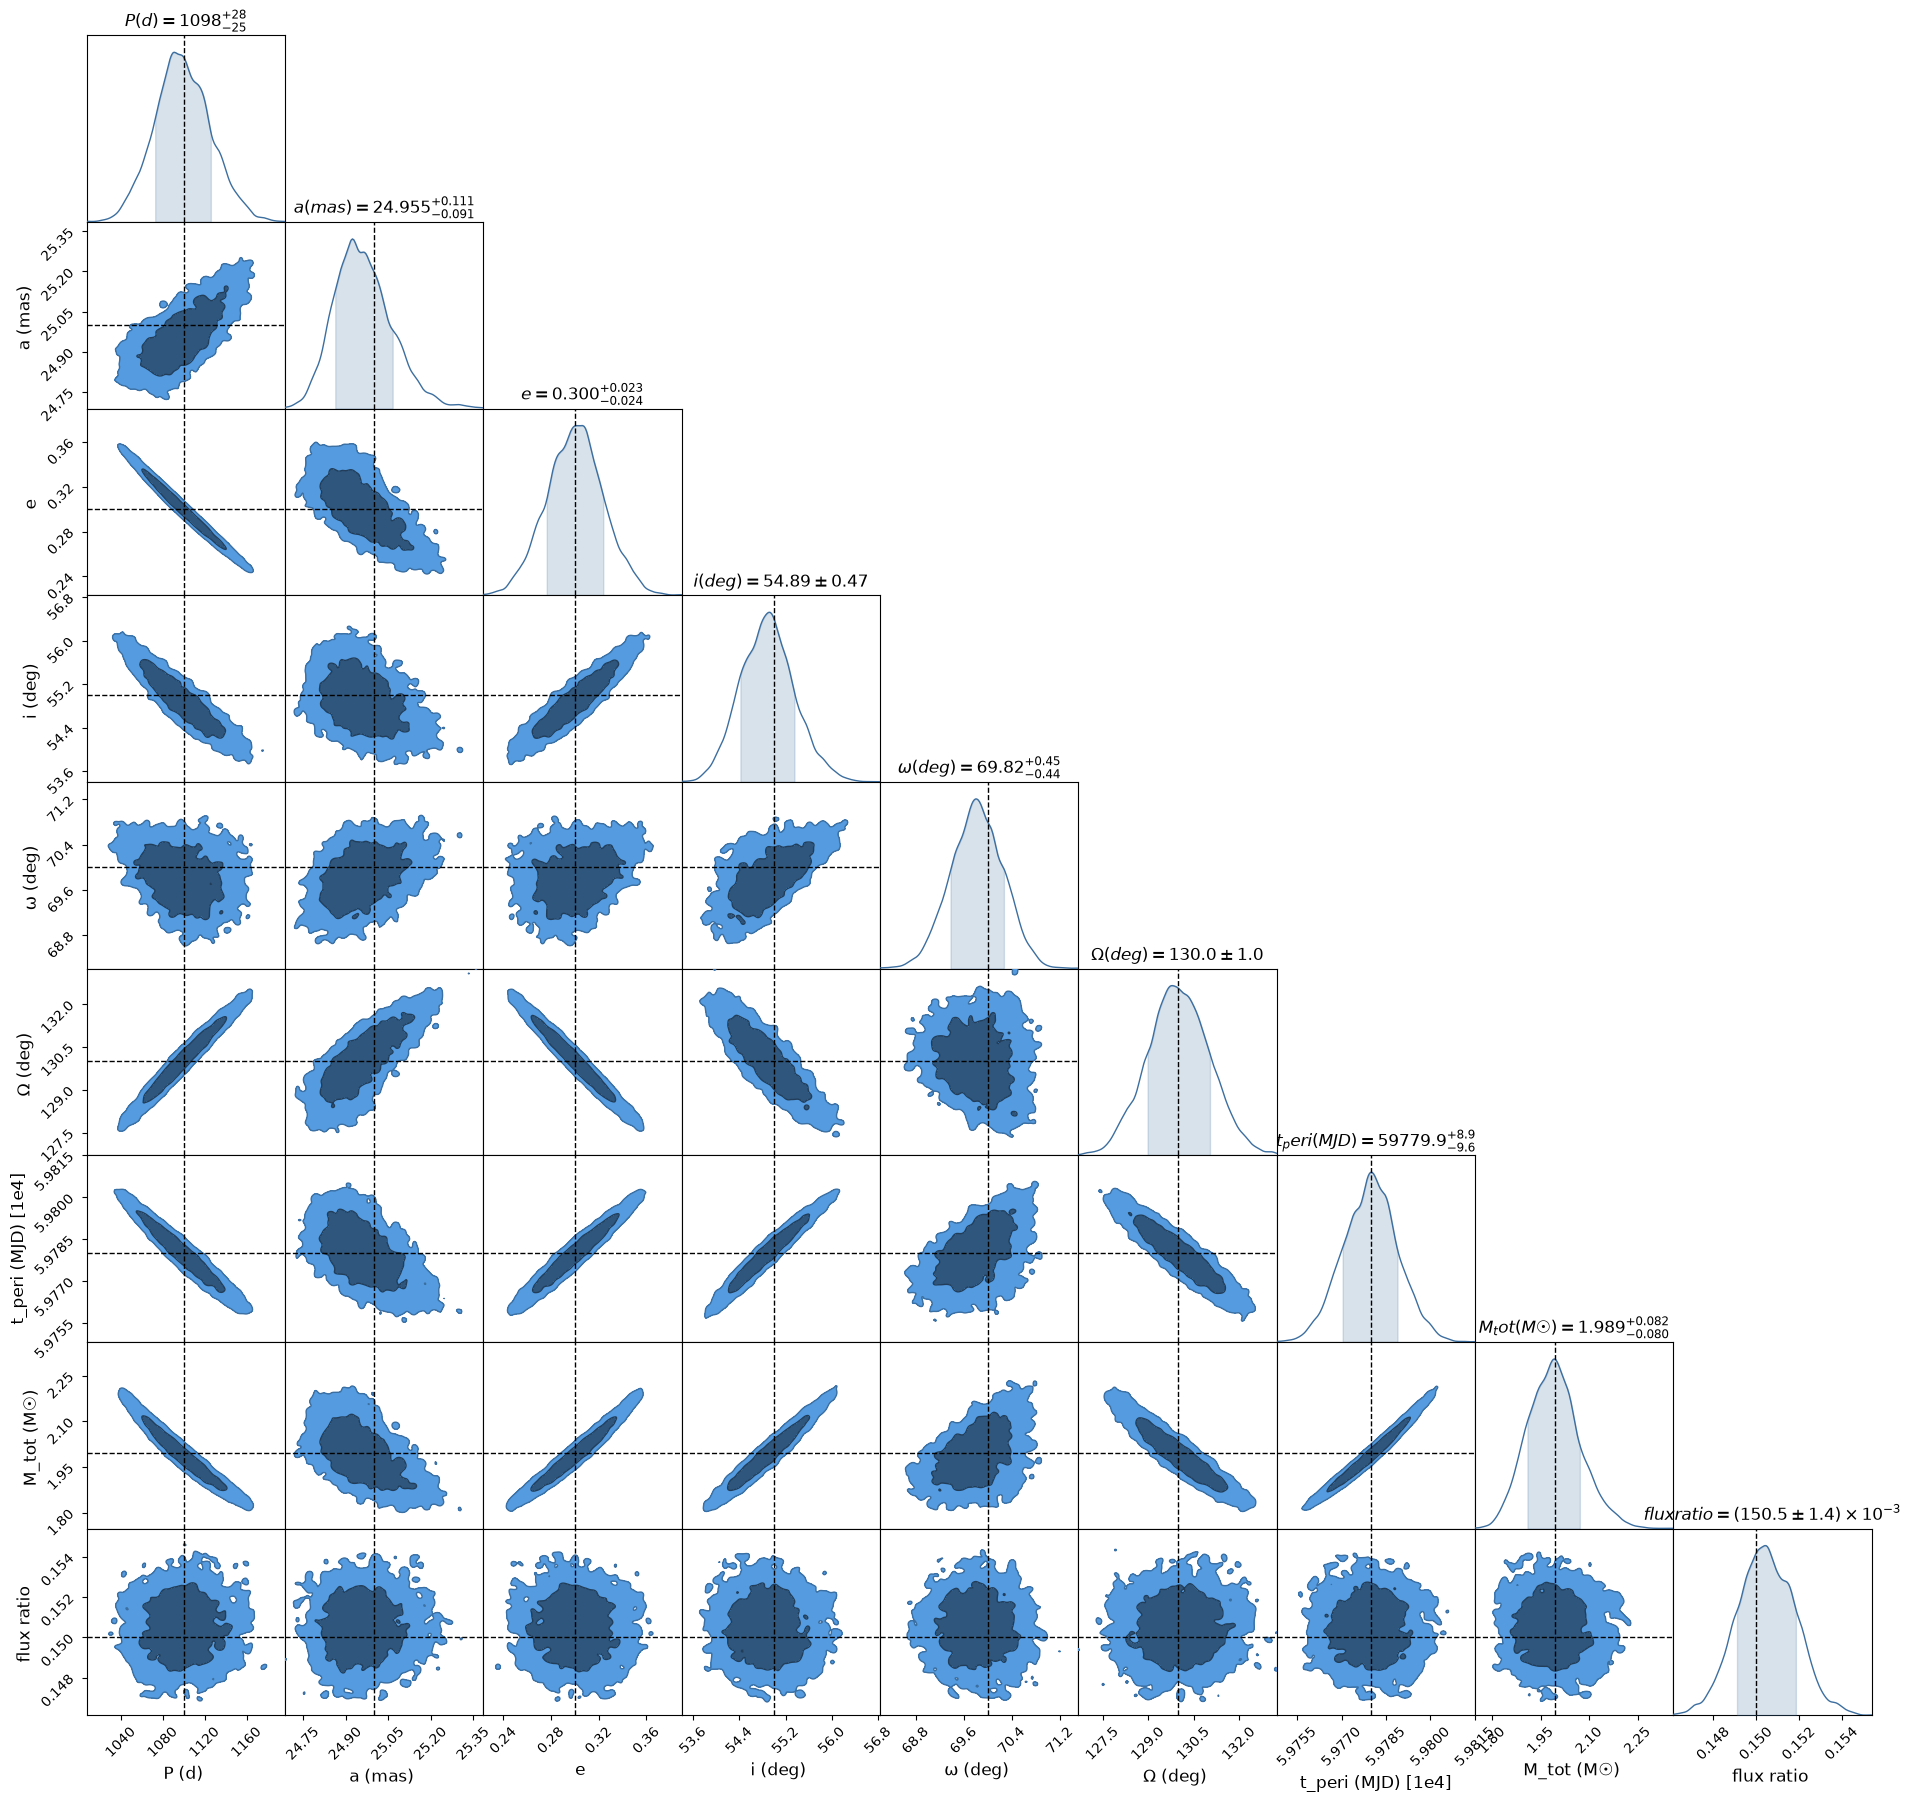

In [14]:
_, corner_fig, walks_fig = plot_chainconsumer_diagnostics(
    {"joint NUTS": table},
    columns=list(table.columns),
    truth=truths,
    colors=["#3c6e9f"],
)
plt.close(walks_fig)  # the chains' traces are not needed here
plt.show()

### Orbits on the sky

What an observer needs to know is where the companion can be. We draw 150 orbits from the posterior and plot them with [`plot_orbit_ensemble`](api/plotting.md), with the primary at the origin and the true orbit in red. The markers are the companion's positions at the eight epochs implied by the posterior: at each epoch's mean time we take the mean and covariance of the position over all the samples, a derived quantity of the joint fit, and wrap them in a `PositionData` for the plot (their 1σ ellipses are far smaller than the markers).

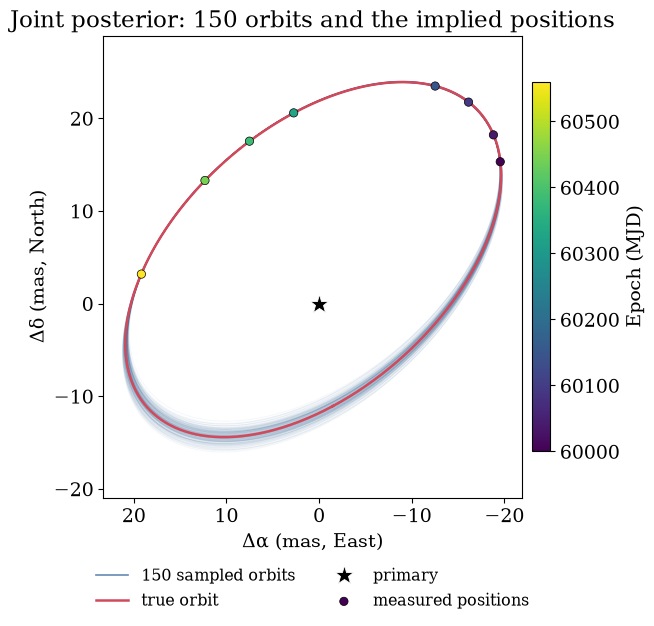

In [15]:
dra_t, ddec_t, _ = (np.asarray(x) for x in orbits.relative(epoch_mjd[:, None]))
# dra_t, ddec_t: (epoch, sample)
implied_cov = np.array(
    [np.cov(np.stack([dra_t[k], ddec_t[k]])) for k in range(N_EPOCHS)]
)
implied = PositionData(
    epoch_mjd, dra_t.mean(axis=1), ddec_t.mean(axis=1), implied_cov, t_ref=T_REF
)
pick = np.random.default_rng(7).choice(len(table), 150, replace=False)
ensemble = orbit_from({k: v[pick] for k, v in samples.items()})
fig, ax = plot_orbit_ensemble(ensemble, implied, truth_orbit)
ax.set_title("Joint posterior: 150 orbits and the implied positions")
plt.show()

Zooming in on each epoch shows those implied positions properly. Each panel shows the posterior samples of the companion's position at that epoch's mean time, relative to the true position, in microarcseconds. The orbit ties each night to the others, so even the worst-calibrated epochs are pinned about as tightly as the best, and the true position (red cross) should fall within each cloud.

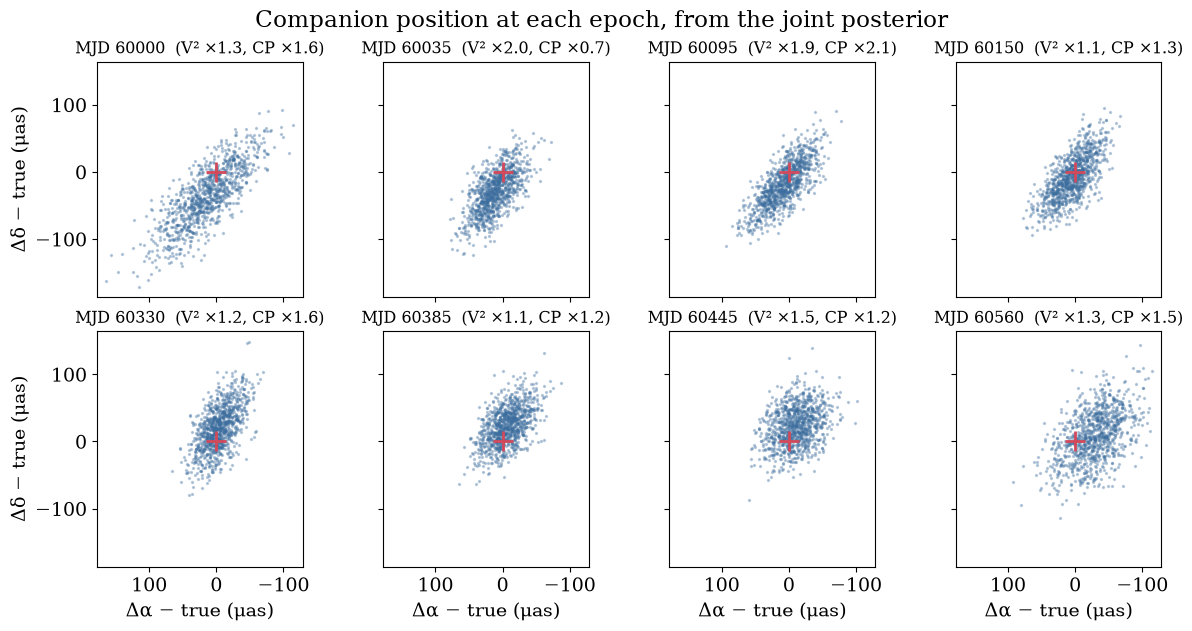

In [16]:
fig, axes = plt.subplots(
    2, 4, figsize=(12, 6.2), sharex=True, sharey=True, constrained_layout=True
)
thin = slice(None, None, 4)
for k, ax in enumerate(axes.flat[:N_EPOCHS]):
    off_ra = 1e3 * (dra_t[k] - true_dra[k])
    off_de = 1e3 * (ddec_t[k] - true_ddec[k])
    ax.scatter(off_ra[thin], off_de[thin], s=2, color="#3c6e9f", alpha=0.3)
    ax.plot(0, 0, "+", color="#d1495b", ms=14, mew=2)
    ax.set_title(
        f"MJD {epoch_mjd[k]:.0f}  (V² ×{TRUE_V2_SCALE[k]:.1f}, "
        f"CP ×{TRUE_CP_SCALE[k]:.1f})",
        fontsize="small",
    )
    ax.set_aspect("equal")
axes[0, 0].invert_xaxis()  # East to the left (shared by every panel)
for ax in axes[-1]:
    ax.set_xlabel("Δα − true (μas)")
for ax in axes[:, 0]:
    ax.set_ylabel("Δδ − true (μas)")
fig.suptitle("Companion position at each epoch, from the joint posterior")
plt.show()

### Separation and position angle in time

The same draws as functions of time show when the uncertainty matters. Separation and position angle are tightly pinned during the two observed seasons and spread out towards the next periastron (dotted line), which is therefore the most valuable time for the next observation. The position angle increases with time, as it should for an inclination below 90°.

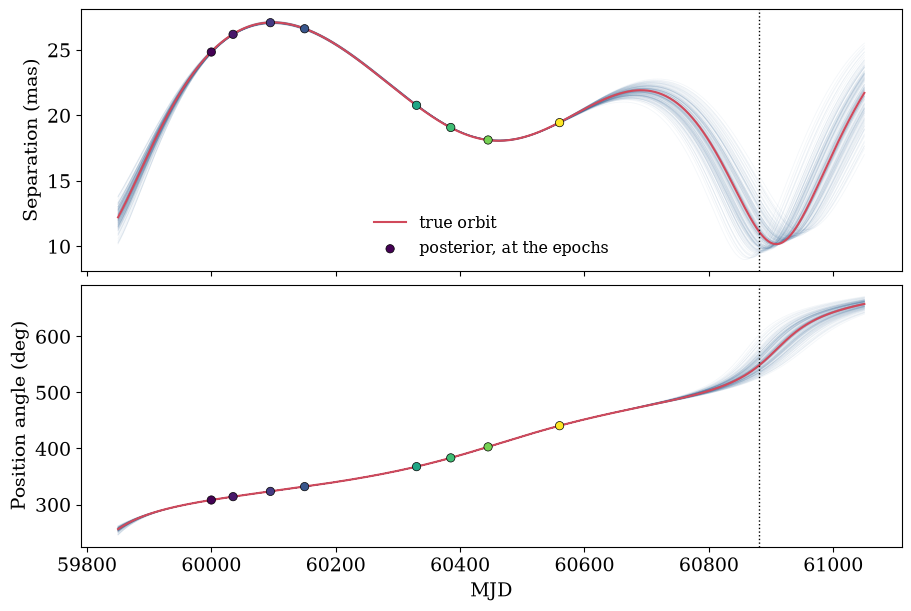

In [17]:
times = T_REF + np.linspace(-430.0, 770.0, 600)


def unwrapped_pa(pa):
    # Position angles as continuous curves, starting in [0, 360).
    return np.degrees(np.unwrap(np.radians(np.asarray(pa)), axis=-1))


sep, pa = jax.vmap(lambda orbit: orbit.separation_pa(times))(ensemble)
true_sep, true_pa = truth_orbit.separation_pa(times)
true_pa = unwrapped_pa(true_pa)
pa = unwrapped_pa(pa)
pa += 360.0 * np.round((true_pa[0] - pa[:, :1]) / 360.0)
implied_sep = np.hypot(implied.dra, implied.ddec)
implied_pa = np.degrees(np.arctan2(implied.dra, implied.ddec))
near = np.interp(epoch_mjd, times, true_pa)  # same branch as the curves
implied_pa += 360.0 * np.round((near - implied_pa) / 360.0)

fig, axes = plt.subplots(
    2, 1, figsize=(9, 6), sharex=True, constrained_layout=True
)
curves = (
    (np.asarray(sep), np.asarray(true_sep), implied_sep, "Separation (mas)"),
    (pa, true_pa, implied_pa, "Position angle (deg)"),
)
for ax, (draws_t, true_t, at_epochs, label) in zip(axes, curves):
    ax.plot(times, draws_t.T, color="#3c6e9f", lw=0.6, alpha=0.06)
    ax.plot(times, true_t, color="#d1495b", lw=1.5, label="true orbit")
    ax.scatter(
        epoch_mjd,
        at_epochs,
        c=epoch_mjd,
        cmap="viridis",
        s=36,
        edgecolors="k",
        linewidths=0.5,
        zorder=3,
        label="posterior, at the epochs",
    )
    ax.axvline(next_peri, color="k", ls=":", lw=1)
    ax.set_ylabel(label)
axes[0].legend(frameon=False, fontsize="small")
axes[1].set_xlabel("MJD")
plt.show()

## Checking the model against the data

A posterior is only as good as the model. We draw 200 samples, predict the closure phases of two epochs, the best and the worst calibrated, and compare them with the data. The top panels show the data with their quoted errors and the posterior-predictive band; the bottom panels show the residuals in units of the quoted errors times that epoch's fitted closure-phase scale, which should scatter as a unit normal. (The closure phases of four telescopes are correlated, so neighbouring residuals are not quite independent.)

MJD 60035: rms residual 0.90 σ over 72 closure phases


MJD 60095: rms residual 1.02 σ over 72 closure phases


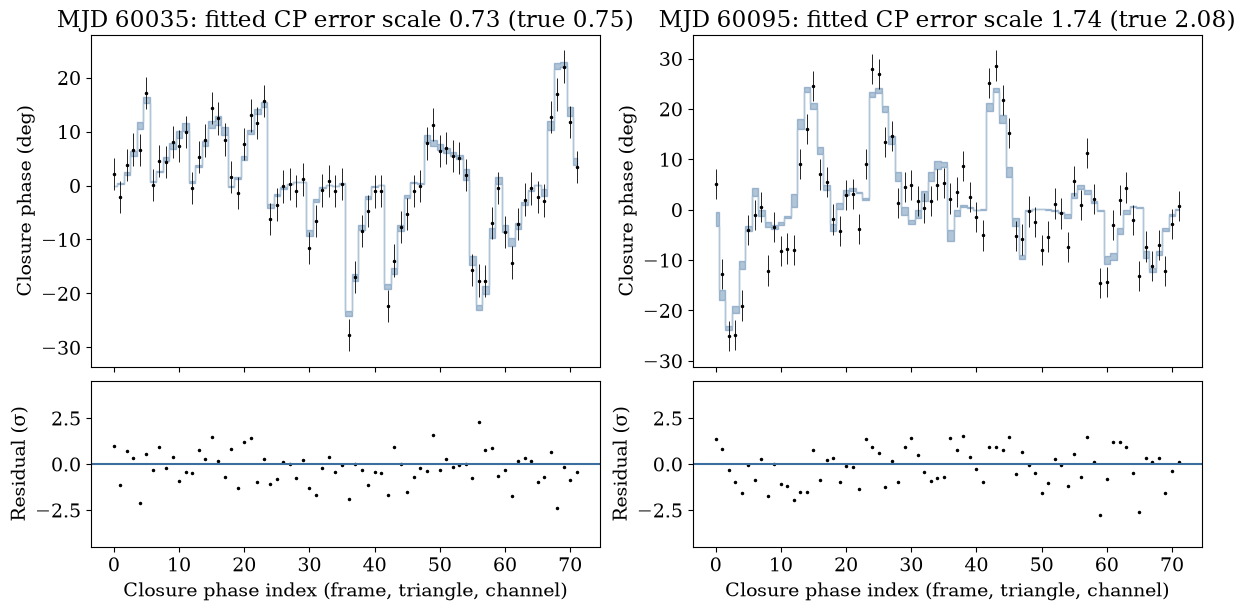

In [18]:
ppc_pick = np.random.default_rng(8).choice(len(table), 200, replace=False)
ppc_samples = {k: v[ppc_pick] for k, v in samples.items()}
shown = [int(np.argmin(TRUE_CP_SCALE)), int(np.argmax(TRUE_CP_SCALE))]
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 6),
    sharex="col",
    gridspec_kw={"height_ratios": [2, 1]},
    constrained_layout=True,
)
for col, k in enumerate(shown):
    night = epochs[k]
    n_vis = night.vis.size

    def predict(row, night=night, n_vis=n_vis):
        prediction = night.model(scene_fn(**row))
        return prediction[n_vis : n_vis + night.phi.size]

    model_cp = np.degrees(np.asarray(jax.vmap(predict)(ppc_samples)))
    data_cp = np.degrees(np.asarray(night.phi))
    quoted = np.degrees(np.asarray(night.d_phi))
    scale = np.median(np.asarray(samples[f"noise[{k}].phi_scale"]))
    index = np.arange(data_cp.size)
    lo, mid, hi = np.percentile(model_cp, [2.5, 50, 97.5], axis=0)
    top, bottom = axes[0, col], axes[1, col]
    top.errorbar(index, data_cp, quoted, fmt=".", color="k", ms=3, lw=0.6)
    top.fill_between(index, lo, hi, color="#3c6e9f", alpha=0.4, step="mid")
    top.set(
        ylabel="Closure phase (deg)",
        title=f"MJD {epoch_mjd[k]:.0f}: fitted CP error scale {scale:.2f}"
        f" (true {TRUE_CP_SCALE[k]:.2f})",
    )
    residual = (data_cp - mid) / (quoted * scale)
    bottom.plot(index, residual, ".", color="k", ms=3)
    bottom.axhline(0, color="#3c6e9f")
    bottom.set(
        xlabel="Closure phase index (frame, triangle, channel)",
        ylabel="Residual (σ)",
        ylim=(-4.5, 4.5),
    )
    print(
        f"MJD {epoch_mjd[k]:.0f}: rms residual {np.std(residual):.2f} σ "
        f"over {residual.size} closure phases"
    )
plt.show()

### The inferred calibration

The error scales are part of the posterior too. Each epoch's $V^2$ and closure-phase factors are recovered (median and 68% interval against the truth), and the population's median and spread, which describe how far the "pipeline" errors are off, can be compared with the population the factors were drawn from (median 1.3, spread 0.3); with only eight draws per population, the spread in particular is loosely constrained.

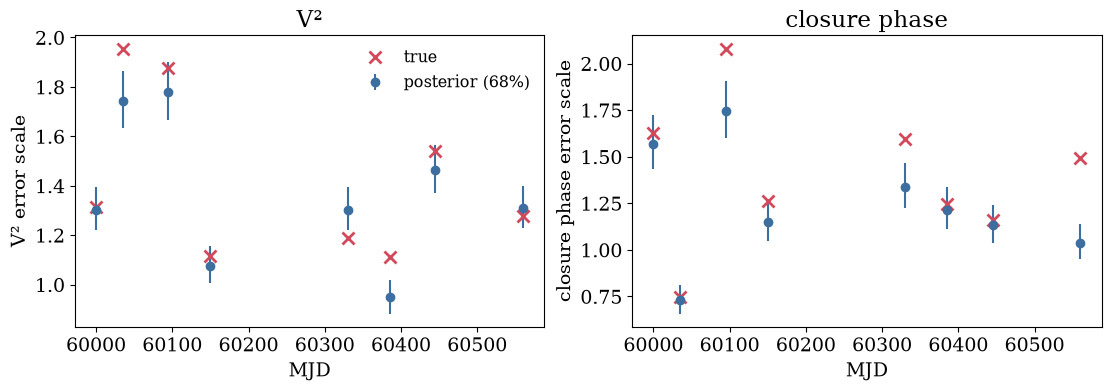

V²             population median 1.34 +0.12 −0.11
V²             population spread 0.24 +0.09 −0.06
closure phase  population median 1.21 +0.15 −0.12
closure phase  population spread 0.29 +0.11 −0.07


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
for ax, (name, term, true_scale) in zip(
    axes,
    [
        ("V²", "vis_scale", TRUE_V2_SCALE),
        ("closure phase", "phi_scale", TRUE_CP_SCALE),
    ],
):
    fitted = np.array(
        [np.asarray(samples[f"noise[{k}].{term}"]) for k in range(N_EPOCHS)]
    )
    lo, mid, hi = np.percentile(fitted, [16, 50, 84], axis=1)
    ax.errorbar(
        epoch_mjd, mid, [mid - lo, hi - mid], fmt="o", color="#3c6e9f",
        label="posterior (68%)",
    )
    ax.plot(epoch_mjd, true_scale, "x", color="#d1495b", ms=9, mew=2,
            label="true")
    ax.set(xlabel="MJD", ylabel=f"{name} error scale", title=name)
axes[0].legend(frameon=False, fontsize="small")
plt.show()

for prefix, label in (("v2_scale", "V²"), ("cp_scale", "closure phase")):
    for part in ("median", "spread"):
        lo, mid, hi = np.percentile(samples[f"{prefix}_{part}"], [16, 50, 84])
        print(
            f"{label:14s} population {part:6s} {mid:.2f} "
            f"+{hi - mid:.2f} −{mid - lo:.2f}"
        )

## Comparison with the two-step fit

For comparison we run the classical two-step analysis on the same data. At each epoch we fit a static binary (`BinaryModelCartesian`) from the grid's best point, take its Laplace covariance, [`laplace_cov`](api/inference.md), at face value with the quoted errors, as such a pipeline usually does, and then sample the orbit from the positions alone with the same orbit priors. The table compares the two posteriors: for each element, the median, the 68% half-width, and the offset of the median from the truth in units of that half-width (a "pull"; honest intervals give pulls of order 1).

In [20]:
binary_priors = {
    "dra": dist.Uniform(-50.0, 50.0),
    "ddec": dist.Uniform(-50.0, 50.0),
    "flux": dist.LogUniform(1e-3, 1.0),
}
names = ["dra", "ddec", "flux"]
per_epoch = []
for night, q in tqdm(list(zip(epochs, quick)), desc="per-epoch fits"):
    start = BinaryModelCartesian(q["dra"], q["ddec"], q["flux"])
    result = fit(start, binary_priors, night)
    values = [float(result.values[k]) for k in names]
    cov = np.asarray(laplace_cov(values, names, night, result.model))
    per_epoch.append((values, cov[:2, :2]))
measured = PositionData(
    epoch_mjd,
    [v[0] for v, _ in per_epoch],
    [v[1] for v, _ in per_epoch],
    np.array([c for _, c in per_epoch]),
    t_ref=T_REF,
)
positions_model = numpyro_model(
    lambda **v: None,
    orbit_priors,
    (),
    likelihoods=[measured.term(orbit_from)],
)
two_step = run_nuts(
    positions_model,
    seed=4,
    num_warmup=NUM_WARMUP,
    num_samples=NUM_SAMPLES,
    num_chains=NUM_CHAINS,
    init={k: best.values[k] for k in best.values if k.split("_vec")[0] in orbit_priors},
)
print(
    "two-step divergences: "
    f"{int(two_step.get_extra_fields()['diverging'].sum())}"
)

per-epoch fits:   0%|          | 0/8 [00:00<?, ?it/s]

two-step divergences: 0


In [21]:
two = {k: np.asarray(v, dtype=float) for k, v in two_step.get_samples().items()}
two_orbits = orbit_from(two)
compare = {
    "P (d)": (samples["period"], two["period"], TRUTH["period"]),
    "a (mas)": (samples["a_mas"], two["a_mas"], TRUTH["a_mas"]),
    "e": (samples["ecc"], two["ecc"], TRUTH["ecc"]),
    "i (deg)": (samples["inc"], two["inc"], TRUTH["inc"]),
    "t_peri (MJD)": (
        T_REF + np.asarray(orbits.dt_peri),
        T_REF + np.asarray(two_orbits.dt_peri),
        T_PERI,
    ),
    "M_tot (M☉)": (
        np.asarray(total_mass(orbits, DISTANCE_PC)),
        np.asarray(total_mass(two_orbits, DISTANCE_PC)),
        float(total_mass(truth_orbit, DISTANCE_PC)),
    ),
}
rows = []
for name, (joint_s, two_s, truth) in compare.items():
    row = {"element": name, "truth": truth}
    for label, s in (("joint", joint_s), ("two-step", two_s)):
        lo, mid, hi = np.percentile(s, [16, 50, 84])
        half = (hi - lo) / 2
        row[f"{label} median"] = mid
        row[f"{label} ±"] = half
        row[f"{label} pull"] = (mid - truth) / half
    rows.append(row)
comparison = pd.DataFrame(rows).set_index("element")
print(comparison.to_string(float_format=lambda x: f"{x:.3g}"))
widths = comparison["joint ±"] / comparison["two-step ±"]
pulls = comparison[["joint pull", "two-step pull"]].abs()
print(
    f"\njoint / two-step interval width: {widths.min():.2f} to "
    f"{widths.max():.2f}"
)
print(
    f"rms pull: joint {np.sqrt(np.mean(pulls['joint pull'] ** 2)):.2f}, "
    f"two-step {np.sqrt(np.mean(pulls['two-step pull'] ** 2)):.2f}"
)

                truth  joint median  joint ±  joint pull  two-step median  two-step ±  two-step pull
element                                                                                             
P (d)         1.1e+03       1.1e+03     26.2     -0.0675         1.09e+03        18.6         -0.534
a (mas)            25            25    0.101      -0.443             24.9      0.0753         -0.832
e                 0.3           0.3   0.0235      0.0163            0.307      0.0169          0.425
i (deg)            55          54.9    0.463      -0.238               55       0.336          0.079
t_peri (MJD) 5.98e+04      5.98e+04     9.15    -0.00533         5.98e+04        6.46          0.431
M_tot (M☉)       1.99          1.99   0.0805     -0.0652             2.01       0.058          0.347

joint / two-step interval width: 1.33 to 1.42
rms pull: joint 0.21, two-step 0.50


Read the table in two ways. The interval widths say how much each analysis claims to know, and the pulls say whether that claim is justified. The two-step positions carry the quoted errors, which are too small by the factors we simulated, so its intervals reflect the quoted precision rather than the real one; the joint fit learns each night's error scale from the data themselves and propagates it into the orbit. Each epoch's position is also no longer reduced to a Gaussian before the orbit sees it. On real data, with skewed or multi-peaked nightly likelihoods, that is where the two analyses differ most. The two-step fit remains a good quick look, and a source of starting orbits, as in the initialisation above.

## Summary

We simulated eight epochs of VLTI-like squared visibilities and closure phases of a binary with a three-year orbit, with nightly errors that are wrong by different amounts, and fitted one model to all of them: a Keplerian orbit placing the companion at the time of every sample, a flux ratio, and per-epoch $V^2$ and closure-phase error scales drawn from fitted populations. Every prior is the invariant prior of its parameter, and a no-data run reproduced them. Coarse per-epoch grids and a Thiele–Innes grid, ranked by the likelihood of all the data, gave the starting orbit; NUTS then sampled the joint posterior. The outputs are the orbit and its derived quantities, the positions it implies at each epoch, posterior-predictive checks against the closure phases, and the inferred calibration.

Practical notes for real data:

- **Expect multimodal nights.** Seed starting orbits from decisive nights only, rank candidates by the joint likelihood of all the data, and refine several. The (Ω, ω) mirror is removed by sampling 2Ω and ϖ; period aliases are not, and need the refined starts (or chains in each mode) to be compared.
- **Fit the calibration.** Per-epoch error scales are cheap and usually matter; the population tells you how far the pipeline's errors are off. For epochs with few data, the non-centred form, `hierarchical_scales(..., centred=False)`, can sample better.
- **Choose what to fit.** Real $V^2$ calibrations are often poorer than closure phases; dropping $V^2$, or giving it gains (see [`OIData.with_gains`](api/oidata.md)), is a common choice, as is cutting wavelength channels affected by telluric or stellar features.
- **Run it where it is fast.** Each joint MAP fit and each NUTS run evaluates the whole dataset at every step; on real data with many frames this is a job for a cluster CPU or a GPU.

Where to go next: scenes with more than two point stars attach other components to the same orbit with `Attached` (the worked example [`notebooks/mwe/mwe_orbit.ipynb`](https://github.com/benjaminpope/virgil/blob/main/notebooks/mwe/mwe_orbit.ipynb) adds a disc around the companion; the design is in [`design/orbit_scene_joint_fitting.md`](https://github.com/benjaminpope/virgil/blob/main/design/orbit_scene_joint_fitting.md)), radial velocities join through `RVData.term` and fix the node, and [Binary search](binary_search.md) covers the single-epoch grid and sampler in more detail.